# SHAP Analysis — FraudLens XGBoost

Explains the tuned XGBoost model (xgb_tuned_v1.joblib) via TreeSHAP.

Sections:
1. Load model + data
2. TreeExplainer setup
3. Global importance (beeswarm + bar)
4. Feature dependence plots
5. Single-sample waterfall (fraud vs legit)
6. Per-transaction SHAP function for agent pipeline
7. Save SHAP summary

## 1. Imports & paths

In [13]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

src_path = str(Path('../src').resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 6)
shap.initjs()

PROC_DIR = Path('../data/processed')
assert PROC_DIR.exists(), f'{PROC_DIR.resolve()} not found'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load model & data

In [14]:
model = joblib.load(PROC_DIR / 'xgb_tuned_v1.joblib')
print(f'Best iteration : {model.best_iteration}')
print(f'Best score     : {model.best_score:.4f}')

train = pd.read_parquet(PROC_DIR / 'train.parquet')
val   = pd.read_parquet(PROC_DIR / 'val.parquet')
test  = pd.read_parquet(PROC_DIR / 'test.parquet')

DROP_COLS = ['TransactionID', 'TransactionDT', 'uid']
TARGET = 'isFraud'
feature_cols = [c for c in train.columns if c not in DROP_COLS + [TARGET]]

X_train, y_train = train[feature_cols], train[TARGET]
X_val,   y_val   = val[feature_cols],   val[TARGET]
X_test,  y_test  = test[feature_cols],  test[TARGET]

print(f'Features : {len(feature_cols)}')
print(f'X_val    : {X_val.shape}')

Best iteration : 1995
Best score     : 0.4833
Features : 79
X_val    : (88581, 79)


## 3. TreeExplainer

TreeExplainer computes exact Shapley values in polynomial time for tree ensembles — no approximation needed.

We sample 4 000 rows from the validation set for global plots (full val = 88 k rows, slow to plot).

In [15]:
SAMPLE_N = 4_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val), size=SAMPLE_N, replace=False)
X_sample = X_val.iloc[sample_idx].reset_index(drop=True)
y_sample = y_val.iloc[sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

print(f'SHAP values shape  : {shap_values.values.shape}')
print(f'Expected value     : {explainer.expected_value:.6f}')
print(f'Fraud rate (sample): {y_sample.mean():.4%}')

SHAP values shape  : (4000, 79)
Expected value     : -3.325322
Fraud rate (sample): 3.6000%


## 4. Global importance

### 4a. Beeswarm plot

Each dot is one sample. Position on x-axis = SHAP value (impact on log-odds). Color = feature value (red = high, blue = low).

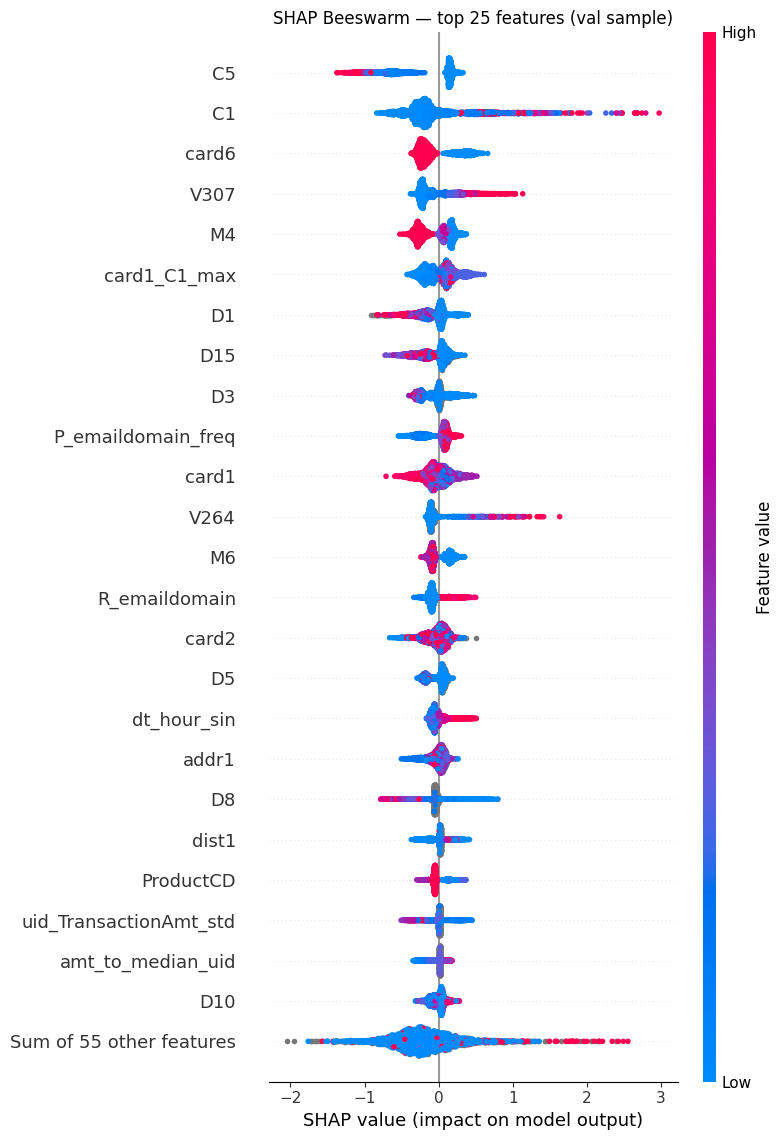

In [16]:
shap.plots.beeswarm(shap_values, max_display=25, show=False)
plt.title('SHAP Beeswarm — top 25 features (val sample)')
plt.tight_layout()
plt.savefig(PROC_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 4b. Bar plot — mean |SHAP|

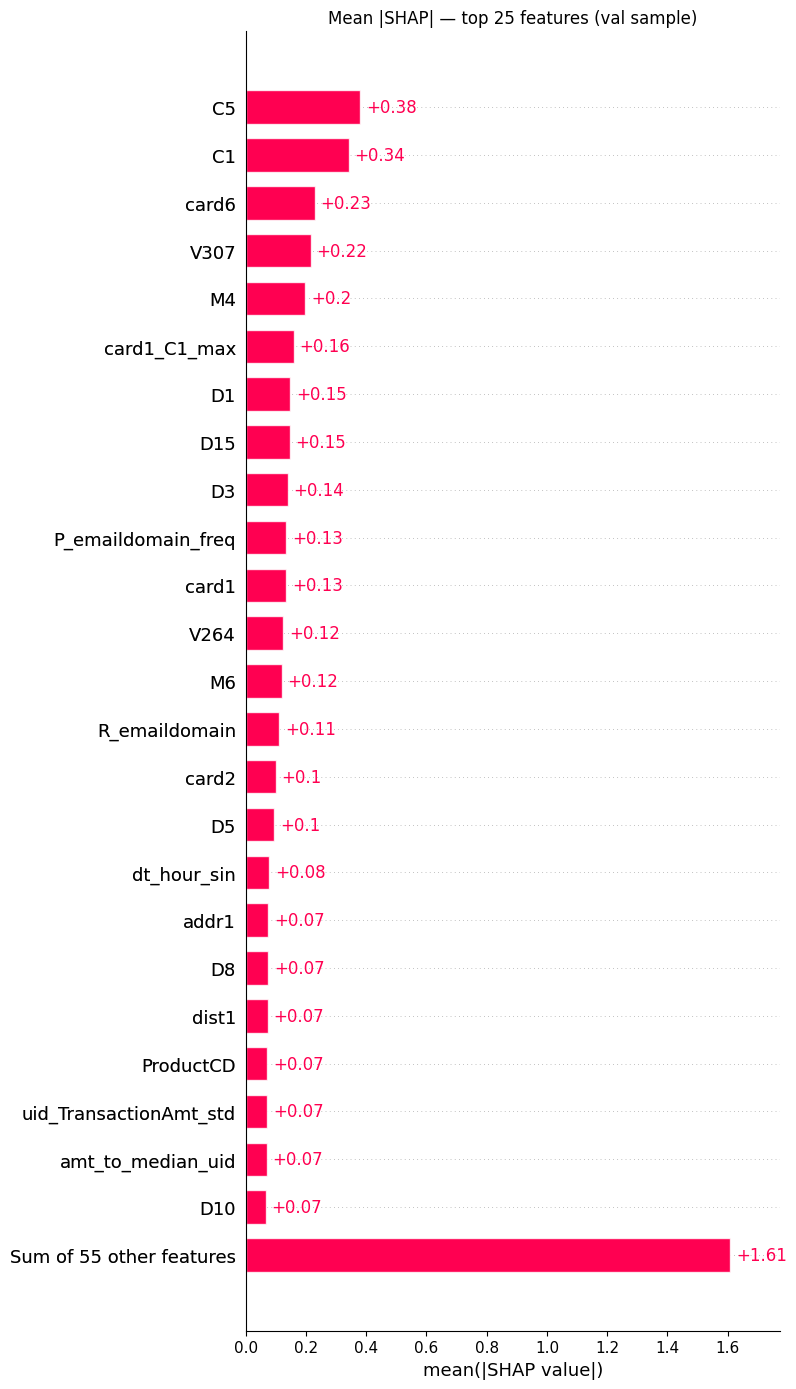

In [17]:
shap.plots.bar(shap_values, max_display=25, show=False)
plt.title('Mean |SHAP| — top 25 features (val sample)')
plt.tight_layout()
plt.savefig(PROC_DIR / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 4c. Feature ranking table

In [18]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_cols,
    name='mean_abs_shap',
).sort_values(ascending=False)

top20 = mean_abs_shap.head(20).reset_index()
top20.columns = ['feature', 'mean_abs_shap']
top20['rank'] = range(1, 21)
top20 = top20[['rank', 'feature', 'mean_abs_shap']]
print(top20.to_string(index=False))

mean_abs_shap.to_csv(PROC_DIR / 'shap_feature_ranking.csv', header=True)

 rank            feature  mean_abs_shap
    1                 C5       0.380106
    2                 C1       0.342149
    3              card6       0.228342
    4               V307       0.216574
    5                 M4       0.197878
    6       card1_C1_max       0.159194
    7                 D1       0.148094
    8                D15       0.146081
    9                 D3       0.139464
   10 P_emaildomain_freq       0.134453
   11              card1       0.134149
   12               V264       0.124801
   13                 M6       0.120478
   14      R_emaildomain       0.112006
   15              card2       0.100542
   16                 D5       0.095509
   17        dt_hour_sin       0.077801
   18              addr1       0.074210
   19                 D8       0.074205
   20              dist1       0.073954


## 5. Dependence plots — top 3 features

Dependence plots show: feature value (x) → SHAP contribution (y).
Color = the most interactive secondary feature (auto-selected by SHAP).

Top 3 by mean |SHAP|: ['C5', 'C1', 'card6']


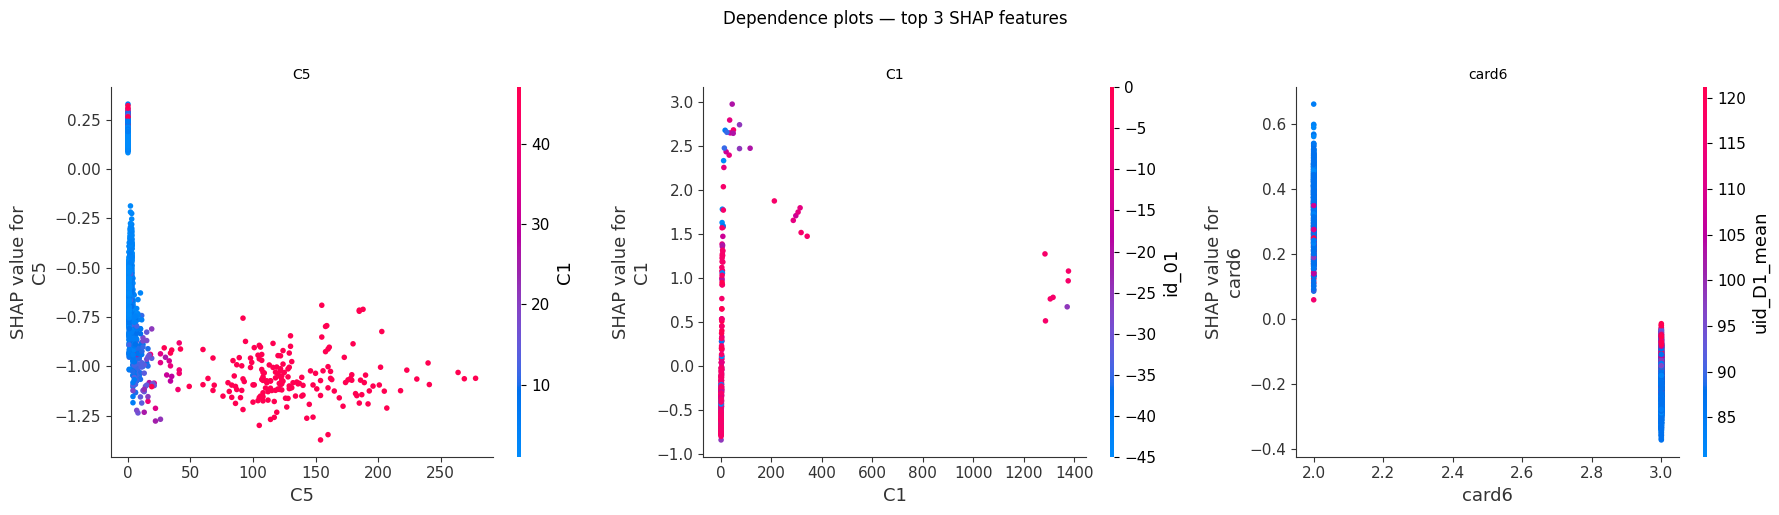

In [19]:
top3_features = mean_abs_shap.index[:3].tolist()
print('Top 3 by mean |SHAP|:', top3_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(
        feat,
        shap_values.values,
        X_sample,
        ax=ax,
        show=False,
    )
    ax.set_title(feat, fontsize=10)

plt.suptitle('Dependence plots — top 3 SHAP features', y=1.02)
plt.tight_layout()
plt.savefig(PROC_DIR / 'shap_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Single-sample waterfall plots

Waterfall plots show how each feature **pushes** the model output above or below the base rate for one specific transaction.
We pick the highest-confidence fraud and the highest-confidence legit from the sample.

In [20]:
proba_sample = model.predict_proba(X_sample)[:, 1]

fraud_mask = y_sample == 1
legit_mask = y_sample == 0

fraud_idx = int(np.argmax(proba_sample * fraud_mask.values))
legit_idx = int(np.argmax((1 - proba_sample) * legit_mask.values))

print(f'Fraud sample idx : {fraud_idx}  |  model score: {proba_sample[fraud_idx]:.4f}')
print(f'Legit sample idx : {legit_idx}  |  model score: {proba_sample[legit_idx]:.4f}')

Fraud sample idx : 912  |  model score: 0.9948
Legit sample idx : 2054  |  model score: 0.0004


--- Waterfall: FRAUD (score=0.9948) ---


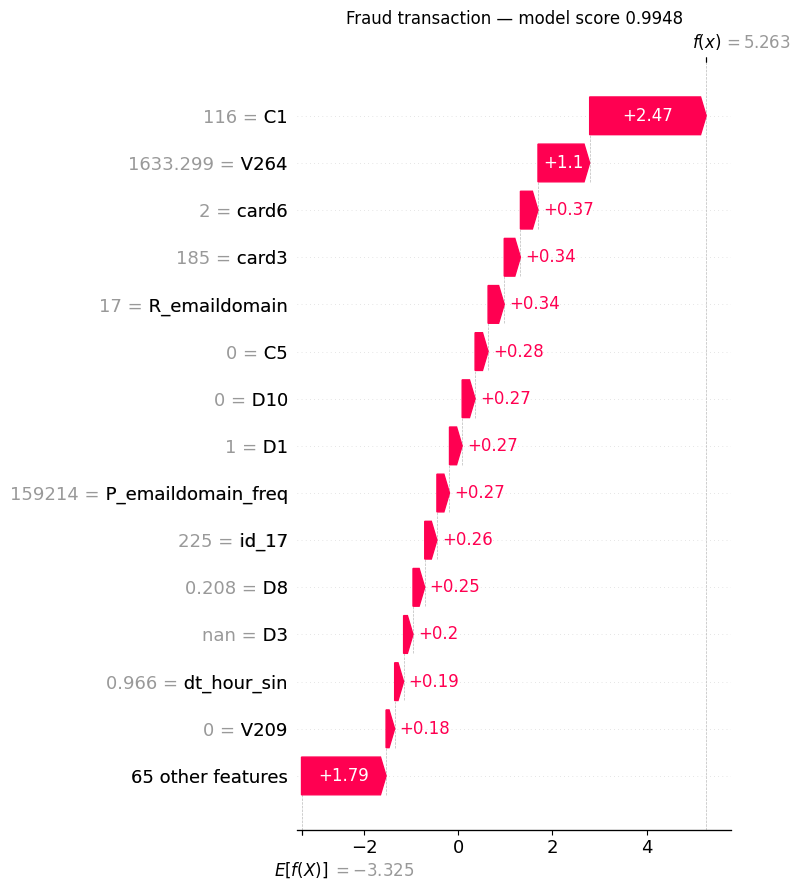

In [21]:
print(f'--- Waterfall: FRAUD (score={proba_sample[fraud_idx]:.4f}) ---')
shap.plots.waterfall(shap_values[fraud_idx], max_display=15, show=False)
plt.title(f'Fraud transaction — model score {proba_sample[fraud_idx]:.4f}')
plt.tight_layout()
plt.savefig(PROC_DIR / 'shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

--- Waterfall: LEGIT (score=0.0004) ---


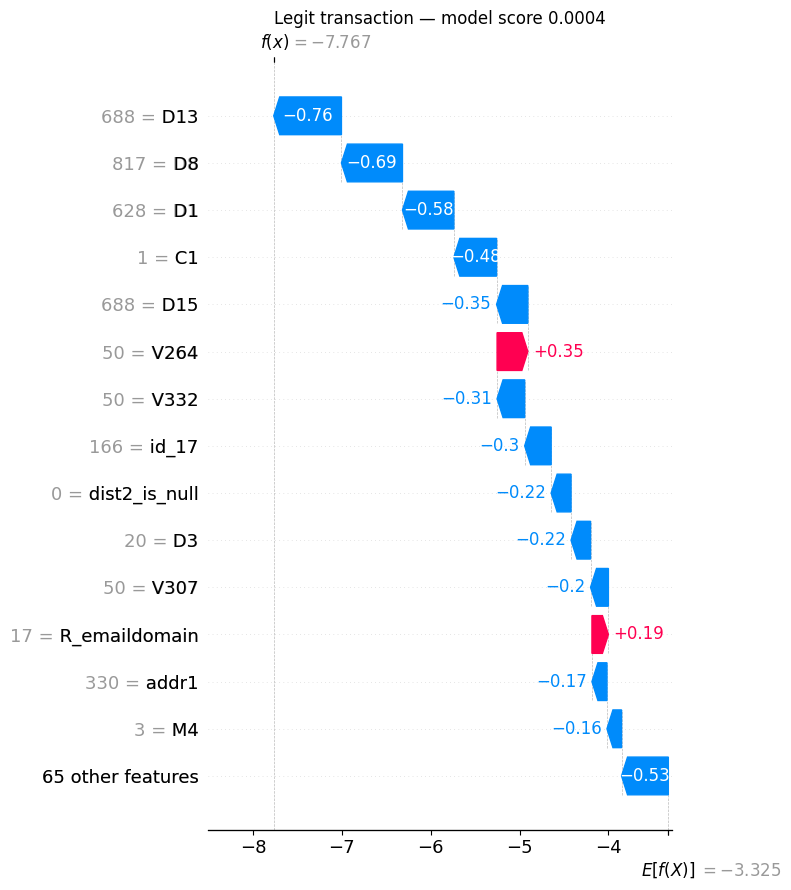

In [22]:
print(f'--- Waterfall: LEGIT (score={proba_sample[legit_idx]:.4f}) ---')
shap.plots.waterfall(shap_values[legit_idx], max_display=15, show=False)
plt.title(f'Legit transaction — model score {proba_sample[legit_idx]:.4f}')
plt.tight_layout()
plt.savefig(PROC_DIR / 'shap_waterfall_legit.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-transaction SHAP — agent pipeline pattern

CLAUDE.md: *"SHAP values computed on every XGBoost prediction, passed as context to agents."*

The function below mirrors what src/fraudlens/ml/scorer.py will call in production.
It returns the **top-k SHAP contributors** as a sorted dict ready to be serialised into an agent prompt.

In [23]:
def explain_transaction(
    row: pd.Series,
    model,
    explainer: shap.TreeExplainer,
    feature_cols: list[str],
    top_k: int = 10,
) -> dict:
    """Return top-k SHAP contributors for a single transaction.

    Returns a dict with keys:
        score        - model fraud probability
        base_value   - explainer expected value (log-odds)
        top_features - list of {feature, value, shap} dicts, sorted by |shap| desc
    """
    X_row = pd.DataFrame([row])
    score = float(model.predict_proba(X_row)[0, 1])

    sv = explainer(X_row)
    shap_series = pd.Series(sv.values[0], index=feature_cols)
    top = shap_series.abs().nlargest(top_k).index

    top_features = [
        {
            'feature': feat,
            'value': float(row[feat]) if pd.notna(row[feat]) else None,
            'shap': round(float(shap_series[feat]), 6),
        }
        for feat in top
    ]

    return {
        'score': round(score, 6),
        'base_value': round(float(explainer.expected_value), 6),
        'top_features': top_features,
    }

In [24]:
import json

fraud_row = X_sample.iloc[fraud_idx]
explanation = explain_transaction(fraud_row, model, explainer, feature_cols, top_k=10)

print('=== Agent payload (fraud transaction) ===')
print(json.dumps(explanation, indent=2))

=== Agent payload (fraud transaction) ===
{
  "score": 0.994847,
  "base_value": -3.325322,
  "top_features": [
    {
      "feature": "C1",
      "value": 116.0,
      "shap": 2.472697
    },
    {
      "feature": "V264",
      "value": 1633.29931640625,
      "shap": 1.096628
    },
    {
      "feature": "card6",
      "value": 2.0,
      "shap": 0.372851
    },
    {
      "feature": "card3",
      "value": 185.0,
      "shap": 0.343567
    },
    {
      "feature": "R_emaildomain",
      "value": 17.0,
      "shap": 0.342801
    },
    {
      "feature": "C5",
      "value": 0.0,
      "shap": 0.27581
    },
    {
      "feature": "D10",
      "value": 0.0,
      "shap": 0.274281
    },
    {
      "feature": "D1",
      "value": 1.0,
      "shap": 0.268918
    },
    {
      "feature": "P_emaildomain_freq",
      "value": 159214.0,
      "shap": 0.266865
    },
    {
      "feature": "id_17",
      "value": 225.0,
      "shap": 0.258648
    }
  ]
}


In [25]:
legit_row = X_sample.iloc[legit_idx]
explanation_legit = explain_transaction(legit_row, model, explainer, feature_cols, top_k=10)

print('=== Agent payload (legit transaction) ===')
print(json.dumps(explanation_legit, indent=2))

=== Agent payload (legit transaction) ===
{
  "score": 0.000423,
  "base_value": -3.325322,
  "top_features": [
    {
      "feature": "D13",
      "value": 688.0,
      "shap": -0.761938
    },
    {
      "feature": "D8",
      "value": 817.0,
      "shap": -0.686903
    },
    {
      "feature": "D1",
      "value": 628.0,
      "shap": -0.578326
    },
    {
      "feature": "C1",
      "value": 1.0,
      "shap": -0.480872
    },
    {
      "feature": "D15",
      "value": 688.0,
      "shap": -0.352031
    },
    {
      "feature": "V264",
      "value": 50.0,
      "shap": 0.346146
    },
    {
      "feature": "V332",
      "value": 50.0,
      "shap": -0.310333
    },
    {
      "feature": "id_17",
      "value": 166.0,
      "shap": -0.298227
    },
    {
      "feature": "dist2_is_null",
      "value": 0.0,
      "shap": -0.22383
    },
    {
      "feature": "D3",
      "value": 20.0,
      "shap": -0.219448
    }
  ]
}


## 8. Save SHAP values & artefacts

In [ ]:
shap_df = pd.DataFrame(
    shap_values.values,
    columns=feature_cols,
)
shap_df['y_true'] = y_sample.values
shap_df['score']  = proba_sample

shap_df.to_parquet(PROC_DIR / 'shap_val_sample.parquet', index=False)

print(f'Saved: {PROC_DIR / "shap_val_sample.parquet"}  ({shap_df.shape})')
print(f'Saved: {PROC_DIR / "shap_feature_ranking.csv"}')
print(f'Saved: {PROC_DIR / "shap_beeswarm.png"}')
print(f'Saved: {PROC_DIR / "shap_bar.png"}')
print(f'Saved: {PROC_DIR / "shap_dependence_top3.png"}')
print(f'Saved: {PROC_DIR / "shap_waterfall_fraud.png"}')
print(f'Saved: {PROC_DIR / "shap_waterfall_legit.png"}')

## Summary

| Artefact | Description |
|---|---|
| `shap_val_sample.parquet` | SHAP matrix (4 000 val rows) + score + label |
| `shap_feature_ranking.csv` | All features ranked by mean |SHAP| |
| `shap_beeswarm.png` | Global importance beeswarm |
| `shap_bar.png` | Global importance bar chart |
| `shap_dependence_top3.png` | Dependence plots for top 3 features |
| `shap_waterfall_fraud.png` | Single-sample explanation (fraud) |
| `shap_waterfall_legit.png` | Single-sample explanation (legit) |

**Next step → `04_mlflow_registration.ipynb`**: log `xgb_tuned_v1.joblib` + SHAP artefacts to MLflow Model Registry.